In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import rankdata, norm
from itertools import product as iproduct

In [20]:
from utils import *
from tests import *

In [21]:
SETTINGS = ["Circular", "Heteroskedastic", "Linear", "Step", "W shaped", "Sinusoid"]

In [22]:
COLORS  = {"MDD": "red", "dCov": "purple", "pMIT [r=0.8]": "orange", "pMIT [formula]": "brown", "Chatterjee": "green", "NCMD [k=5]": "dodgerblue", "NCMD [k=10]" : "navy"}
MARKERS = {"MDD": "P",       "dCov": "s",  "pMIT [r=0.8]": "X",  "pMIT [formula]": "H",     "Chatterjee": "p",       "NCMD [k=5]": "o", "NCMD [k=10]" : "*"}

SETTING_LABELS = {
    "Linear":          "Linear [Power]",
    "Step":            "Step [Power]",
    "W shaped":        "W-Shaped [Power]",
    "Sinusoid":        "Sinusoid [Power]",
    "Circular":        "Circular [Type-I]",
    "Heteroskedastic": "Heteroskedastic [Type-I]",
}

In [23]:
lambda_grid = np.linspace(0, 1, 5)

xgb_params_ = {
    "n_estimators":     4,
    "max_depth":        6,
    "learning_rate":    0.1,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_lambda":       0.0,
    "reg_alpha":        0.0,
    "min_child_weight": 25,
    "verbosity":        0,
    "random_state":     None,
}

methods = {
    "dCov":        lambda X, Y: {"reject": dcov_test(X, Y, n_permutations = 199)["reject"]},
    "MDD":         lambda X, Y: {"reject": mdd_test(X, Y, n_bootstrap = 199)["reject"]},
    "pMIT [r=0.8]":        lambda X, Y: {"reject": pmit_test(X, Y, split_ratio=0.8, xgb_params=xgb_params_)["reject"]},
    "pMIT [formula]":        lambda X, Y: {"reject": pmit_test(X, Y, split_ratio="formula", xgb_params=xgb_params_)["reject"]},
    "Chatterjee":  lambda X, Y: {"reject": chatterjee_test(X, Y)["reject"]},
    "NCMD [k=10]":       lambda X, Y: {"reject": nncmi(X, Y, k = 10)["reject"]},
    "NCMD [k=5]":       lambda X, Y: {"reject": nncmi(X, Y, k = 5)["reject"]},
}

In [24]:
n = 250
n_sim = 200
seed = 42

In [25]:
results_uniform, times_uniform = run_experiment(lambda_grid, methods, SETTINGS, n=n, n_sim=n_sim, X_setting = "uniform", seed=seed)

Running 6 settings in parallel (n_jobs=-1) …

  [Step] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=1.000±0.000  pMIT [formula]=0.250±0.031  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Circular] lambda=0.00  dCov=1.000±0.000  MDD=0.070±0.018  pMIT [r=0.8]=0.120±0.023  pMIT [formula]=0.085±0.020  Chatterjee=1.000±0.000  NCMD [k=10]=0.060±0.017  NCMD [k=5]=0.070±0.018
  [W shaped] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.595±0.035  pMIT [formula]=0.090±0.020  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Linear] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=1.000±0.000  pMIT [formula]=0.210±0.029  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Heteroskedastic] lambda=0.00  dCov=1.000±0.000  MDD=0.105±0.022  pMIT [r=0.8]=0.075±0.019  pMIT [formula]=0.080±0.019  Chatterjee=1.000±0.000  NCMD [k=10]=0.075±0.019  NCMD [k=5]=0.045±0.015
  [Sinusoid] lambd

In [26]:
# with open("results_uniform_univariate_d1_n200_nsim200.pkl", "rb") as f:
#     saved = pickle.load(f)

# results     = saved["results"]
# timings     = saved["timings"]
# lambda_grid = saved["lambda_grid"]

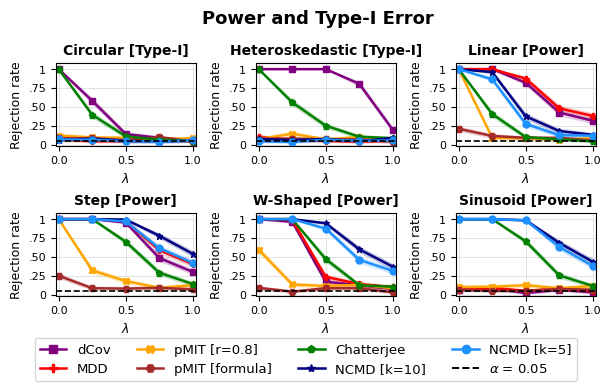

Plot saved → results/power_curves_uniform.pdf


In [27]:
plot_power_curves(results_uniform, SETTING_LABELS, COLORS, MARKERS, lambda_grid, save_path="results/power_curves_uniform.pdf")

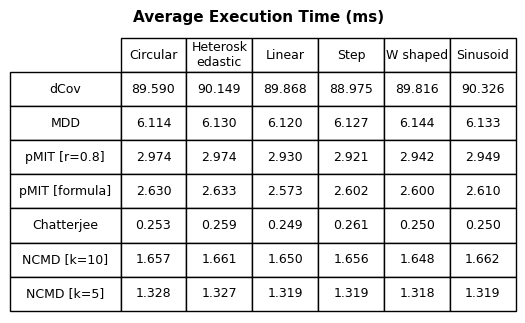

Timing table saved → results/method_times_uniform.pdf


In [28]:
plot_times_table(times_uniform, col_width=0.55, row_height=0.45, max_row_width=15, max_col_width=8, save_path="results/method_times_uniform.pdf")

In [29]:
results_normal, times_normal = run_experiment(lambda_grid, methods, SETTINGS, n=n, n_sim=n_sim, X_setting = "normal", seed=seed)

Running 6 settings in parallel (n_jobs=-1) …

  [W shaped] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.590±0.035  pMIT [formula]=0.095±0.021  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Linear] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.990±0.007  pMIT [formula]=0.210±0.029  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Heteroskedastic] lambda=0.00  dCov=1.000±0.000  MDD=0.055±0.016  pMIT [r=0.8]=0.085±0.020  pMIT [formula]=0.045±0.015  Chatterjee=1.000±0.000  NCMD [k=10]=0.045±0.015  NCMD [k=5]=0.060±0.017
  [Sinusoid] lambda=0.00  dCov=0.045±0.015  MDD=0.045±0.015  pMIT [r=0.8]=0.075±0.019  pMIT [formula]=0.070±0.018  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Circular] lambda=0.00  dCov=1.000±0.000  MDD=0.060±0.017  pMIT [r=0.8]=0.070±0.018  pMIT [formula]=0.060±0.017  Chatterjee=1.000±0.000  NCMD [k=10]=0.045±0.015  NCMD [k=5]=0.040±0.014
  [Step] lambd

In [30]:
# with open("results_normal_univariate_d1_n200_nsim200.pkl", "rb") as f:
#     saved = pickle.load(f)

# results     = saved["results"]
# timings     = saved["timings"]
# lambda_grid = saved["lambda_grid"]

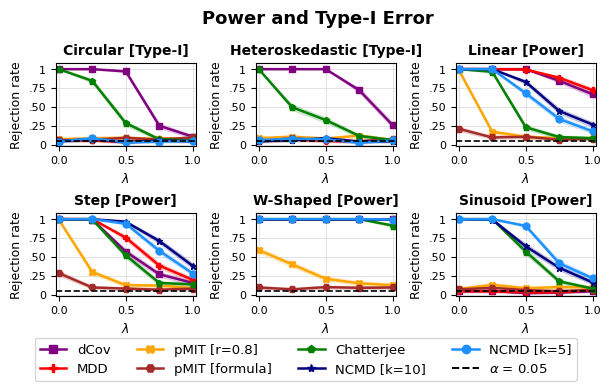

Plot saved → results/power_curves_normal.pdf


In [31]:
plot_power_curves(results_normal, SETTING_LABELS, COLORS, MARKERS, lambda_grid, save_path="results/power_curves_normal.pdf")

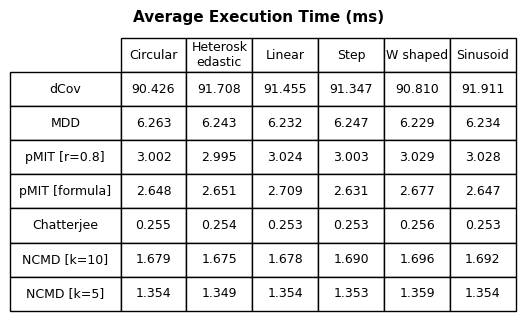

Timing table saved → results/method_times_normal.pdf


In [32]:
plot_times_table(times_normal, col_width=0.55, row_height=0.45, max_row_width=15, max_col_width=8, save_path="results/method_times_normal.pdf")

In [33]:
results_beta, times_beta = run_experiment(lambda_grid, methods, SETTINGS, n=n, n_sim=n_sim, X_setting = "beta", seed=seed)

Running 6 settings in parallel (n_jobs=-1) …

  [Sinusoid] lambda=0.00  dCov=0.995±0.005  MDD=1.000±0.000  pMIT [r=0.8]=0.670±0.033  pMIT [formula]=0.095±0.021  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [W shaped] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.825±0.027  pMIT [formula]=0.050±0.015  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Step] lambda=0.00  dCov=1.000±0.000  MDD=0.980±0.010  pMIT [r=0.8]=0.110±0.022  pMIT [formula]=0.055±0.016  Chatterjee=1.000±0.000  NCMD [k=10]=0.995±0.005  NCMD [k=5]=1.000±0.000
  [Linear] lambda=0.00  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=1.000±0.000  pMIT [formula]=0.120±0.023  Chatterjee=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Heteroskedastic] lambda=0.00  dCov=0.990±0.007  MDD=0.055±0.016  pMIT [r=0.8]=0.120±0.023  pMIT [formula]=0.030±0.012  Chatterjee=1.000±0.000  NCMD [k=10]=0.060±0.017  NCMD [k=5]=0.065±0.017
  [Circular] lambd

In [34]:
# with open("results_beta_univariate_d1_n200_nsim200.pkl", "rb") as f:
#     saved = pickle.load(f)

# results     = saved["results"]
# timings     = saved["timings"]
# lambda_grid = saved["lambda_grid"]

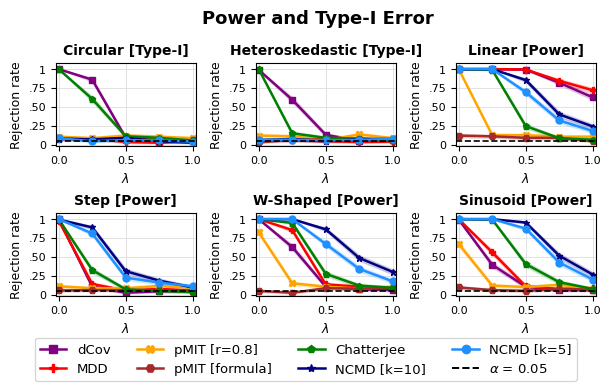

Plot saved → results/power_curves_beta.pdf


In [35]:
plot_power_curves(results_beta, SETTING_LABELS, COLORS, MARKERS, lambda_grid, save_path="results/power_curves_beta.pdf")

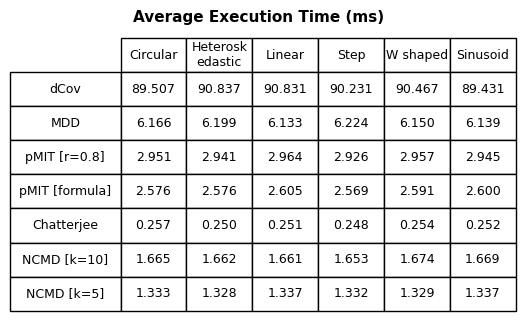

Timing table saved → results/method_times_beta.pdf


In [36]:
plot_times_table(times_beta, col_width=0.55, row_height=0.45, max_row_width=15, max_col_width=8, save_path="results/method_times_beta.pdf")